## 2.1/ Tiền xử lý dữ liệu ảnh số

In [1]:
# Chạy 1 lần, sau đó có thể comment lại
import sys
import subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
    'imagehash', 'scikit-image', 'scikit-learn',
    'scipy', 'tqdm', 'matplotlib', 'seaborn', 'opencv-python', '-q'])
print('✅ Cài đặt hoàn tất!')

✅ Cài đặt hoàn tất!


In [2]:
import zipfile
import os
from tqdm import tqdm

# Chest X-ray dataset — đường dẫn zip và thư mục giải nén
ZIP_PATH    = r'Chest X-rays Image.zip'
EXTRACT_DIR = 'Chest X-rays Image'

if not os.path.exists(os.path.join(EXTRACT_DIR, 'chest_xray')):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    print(f'Đang giải nén: {ZIP_PATH}')
    print('(Có thể mất vài phút...)')

    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        members = zip_ref.infolist()
        for member in tqdm(members, desc='Giải nén'):
            try:
                member.filename = member.filename.encode('cp437').decode('utf-8', errors='replace')
            except Exception:
                pass
            try:
                zip_ref.extract(member, EXTRACT_DIR)
            except Exception as e:
                print(f'⚠️  Bỏ qua: {member.filename} ({e})')
                continue

    print(f'✅ Giải nén xong! Thư mục: {EXTRACT_DIR}')
else:
    print(f'✅ Thư mục đã tồn tại, bỏ qua giải nén: {os.path.join(EXTRACT_DIR, "chest_xray")}')

# Kiểm tra cấu trúc thư mục
print('\nCấu trúc thư mục sau giải nén:')
for root, dirs, files in os.walk(EXTRACT_DIR):
    depth = root.replace(EXTRACT_DIR, '').count(os.sep)
    indent = '  ' * depth
    print(f'{indent}📁 {os.path.basename(root)}/')
    if depth >= 2:
        break

✅ Thư mục đã tồn tại, bỏ qua giải nén: Chest X-rays Image\chest_xray

Cấu trúc thư mục sau giải nén:
📁 Chest X-rays Image/
  📁 chest_xray/
    📁 chest_xray/


In [3]:
import os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from PIL import Image
import imagehash
from tqdm import tqdm
from collections import defaultdict

from scipy import stats
from scipy.stats import ks_2samp, f_oneway
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage import filters, feature

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── Đường dẫn dataset mới ────────────────────────────────────────────────────
# Chest X-ray: chỉ có 2 lớp (PNEUMONIA / NORMAL), ảnh .jpeg
DATASET_PATH = os.path.join('Chest X-rays Image', 'chest_xray')

# ── Tham số — điều chỉnh cho dataset 2 lớp, ~5,200 ảnh ──────────────────────
MAX_SAMPLE       = 6000   # lấy mẫu tối đa để phân tích pixel
                          # (dataset ~5,216 ảnh → lấy gần hết)
MAX_PER_CLASS    = 5000    # mỗi lớp tối đa 500 ảnh cho brightness/contrast
N_CLASSES_SHOW   = 2      # chỉ có 2 lớp: NORMAL và PNEUMONIA
IMG_SIZE_DEFAULT = (128, 128)

# ── Định dạng ảnh của dataset mới là .jpeg ───────────────────────────────────
IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png')

os.makedirs('outputs', exist_ok=True)

# Kiểm tra đường dẫn hợp lệ
if not os.path.exists(DATASET_PATH):
    print(f'❌ Không tìm thấy: {DATASET_PATH}')
    print('💡 Hãy kiểm tra lại đường dẫn ở DATASET_PATH')
else:
    print(f'✅ Tìm thấy dataset: {DATASET_PATH}')
    print(f'✅ Cấu hình hoàn tất. Bắt đầu phân tích...')

✅ Tìm thấy dataset: Chest X-rays Image\chest_xray
✅ Cấu hình hoàn tất. Bắt đầu phân tích...


In [4]:
# ĐỌC CẤU TRÚC DỮ LIỆU — quét toàn bộ train / val / test
from collections import defaultdict
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

IMAGE_EXTS = ('.jpg', '.jpeg', '.png')

# ── Lấy danh sách splits hợp lệ (train / val / test) ──────────────────────────
# Loại bỏ thư mục hệ thống như __MACOSX, hoặc thư mục không chứa class con
VALID_SPLITS = ['train', 'val', 'test']   # thứ tự ưu tiên hiển thị

splits_found = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
    and d in VALID_SPLITS                 # chỉ lấy đúng tên split đã biết
])

print(f'📁 Dataset root : {DATASET_PATH}')
print(f'   Splits tìm thấy: {splits_found}\n')

# ── Quét toàn bộ splits → lớp → ảnh ──────────────────────────────────────────
#   split_data[split][class] = [list of image paths]
split_data = {}

for split in splits_found:
    split_path = os.path.join(DATASET_PATH, split)

    try:
        class_names = sorted([
            d for d in os.listdir(split_path)
            if os.path.isdir(os.path.join(split_path, d))
        ])
    except Exception as e:
        print(f'⚠️  Bỏ qua split "{split}": {e}')
        continue

    class_images_split = {}
    for cls in class_names:
        cls_path = os.path.join(split_path, cls)
        imgs = []
        try:
            for f in os.listdir(cls_path):
                if f.lower().endswith(IMAGE_EXTS):
                    full_path = os.path.join(cls_path, f)
                    try:
                        if os.path.getsize(full_path) > 0:
                            imgs.append(full_path)
                    except OSError as e:
                        print(f'    ⚠️  Bỏ qua file lỗi: {f} ({e})')
        except Exception as e:
            print(f'  ⚠️  Bỏ qua lớp "{cls}" trong "{split}": {e}')

        class_images_split[cls] = imgs

    split_data[split] = class_images_split

# ── In báo cáo chi tiết từng split ───────────────────────────────────────────
print('═' * 45)
print(f'  {"SPLIT":<8}  {"LỚP":<15}  {"SỐ ẢNH":>8}')
print('═' * 45)

grand_total = 0

for split in splits_found:
    if split not in split_data:
        continue

    cls_dict   = split_data[split]
    total_imgs = sum(len(v) for v in cls_dict.values())
    grand_total += total_imgs

    print(f'\n┌─ 📂 {split.upper()}  —  {len(cls_dict)} lớp  |  {total_imgs:,} ảnh')

    # Sắp xếp các lớp theo số lượng ảnh giảm dần
    for cls, paths in sorted(cls_dict.items(), key=lambda x: -len(x[1])):
        cnt = len(paths)
        # Chỉ in ra tên lớp và số lượng ảnh
        print(f'│   ├─ {cls:<15}  {cnt:>8,} ảnh')

print('│')
print(f'└─ 🗂️  TỔNG CỘNG: {grand_total:,} ảnh\n')
print('═' * 45)

📁 Dataset root : Chest X-rays Image\chest_xray
   Splits tìm thấy: ['test', 'train', 'val']

═════════════════════════════════════════════
  SPLIT     LỚP                SỐ ẢNH
═════════════════════════════════════════════

┌─ 📂 TEST  —  2 lớp  |  624 ảnh
│   ├─ PNEUMONIA             390 ảnh
│   ├─ NORMAL                234 ảnh

┌─ 📂 TRAIN  —  2 lớp  |  5,216 ảnh
│   ├─ PNEUMONIA           3,875 ảnh
│   ├─ NORMAL              1,341 ảnh

┌─ 📂 VAL  —  2 lớp  |  16 ảnh
│   ├─ NORMAL                  8 ảnh
│   ├─ PNEUMONIA               8 ảnh
│
└─ 🗂️  TỔNG CỘNG: 5,856 ảnh

═════════════════════════════════════════════


### 2.1.2/ Phân tích dữ liệu tập thống kê
#### 2.1.2a/ Phân phối giá trị pixel trên toàn tập theo từng kênh màu
Để hiểu đặc trưng màu sắc của tập dữ liệu, ta phân tích phân phối giá trị pixel trên từng kênh màu R, G, B riêng biệt. Mỗi pixel có giá trị nguyên trong đoạn [0, 255], với 0 = tối hoàn toàn và 255 = sáng hoàn toàn trên kênh đó. Hai công cụ trực quan hóa được sử dụng kết hợp:
##### 1/ Histogram chuẩn hóa (Normalized Histogram):
$$\hat{f}(x) = \frac{\text{count}(x \in \text{bin})}{N \cdot h}$$
Trong đó:
- $N$: tổng số pixel được lấy mẫu
- $h$: độ rộng mỗi bin (= 1 vì range là 0–255, chia 256 bins)
- $\text{count}(x \in \text{bin})$: số pixel rơi vào bin chứa $x$
Histogram cho thấy tần suất xuất hiện của từng mức pixel, nhưng bị ảnh hưởng bởi kích thước bin. KDE được dùng để làm mượt.
##### 2/ Kernel Density Estimation (KDE):
KDE ước lượng hàm mật độ xác suất liên tục bằng cách đặt một hàm kernel tại mỗi điểm dữ liệu:
$$\hat{f}(x) = \frac{1}{N \cdot h} \sum_{i=1}^{N} K\!\left(\frac{x - x_i}{h}\right)$$
Trong đó $K$ là Gaussian kernel:
$$K(u) = \frac{1}{\sqrt{2\pi}} e^{-\frac{u^2}{2}}$$
Bandwidth $h$ được chọn tự động theo **quy tắc Silverman**
(tối ưu cho phân phối gần chuẩn):
$$h = 0.9 \cdot \min\!\left(\hat{\sigma},\ 
\frac{\text{IQR}}{1.34}\right) \cdot N^{-1/5}$$
Trong đó:
- $\hat{\sigma}$: độ lệch chuẩn mẫu của dữ liệu
- $\text{IQR}$: khoảng tứ phân vị (Q3 − Q1), dùng để robust
  với outlier
- $N^{-1/5}$: hệ số co bandwidth theo kích thước mẫu —
  mẫu càng lớn, đường KDE càng mịn
##### 3/ Các chỉ số thống kê mô tả
Độ lệch (Skewness) - đo mức độ bất đối xứng của phân phối:
$$\text{Skewness} = \frac{E\left[(X - \mu)^3\right]}{\sigma^3}$$
- Skewness $> 0$: đuôi phải dài hơn (lệch phải)
- Skewness $< 0$: đuôi trái dài hơn (lệch trái)
- $|\text{Skewness}| < 0.5$: phân phối gần đối xứng

Độ nhọn (Excess Kurtosis) — đo mức độ "nhọn" của đỉnh so với phân phối chuẩn:
$$\text{Kurtosis} = \frac{E\left[(X - \mu)^4\right]}{\sigma^4} - 3$$
- Kurtosis $> 0$ (leptokurtic): đỉnh nhọn, đuôi dày
- Kurtosis $< 0$ (platykurtic): đỉnh dẹt, đuôi mỏng
- Kurtosis $= 0$: đúng phân phối chuẩn

Đang đọc 4,000 ảnh mẫu để phân tích pixel...
⚠️  Lưu ý: ảnh được resize về (128, 128) trước khi lấy pixel.
    → Mean được bảo toàn tốt; Std có thể bị underestimate ~10–15% so với ảnh gốc.


Đọc pixel: 100%|███████████████████████████████████████████████████████████████████| 4000/4000 [01:45<00:00, 37.79it/s]


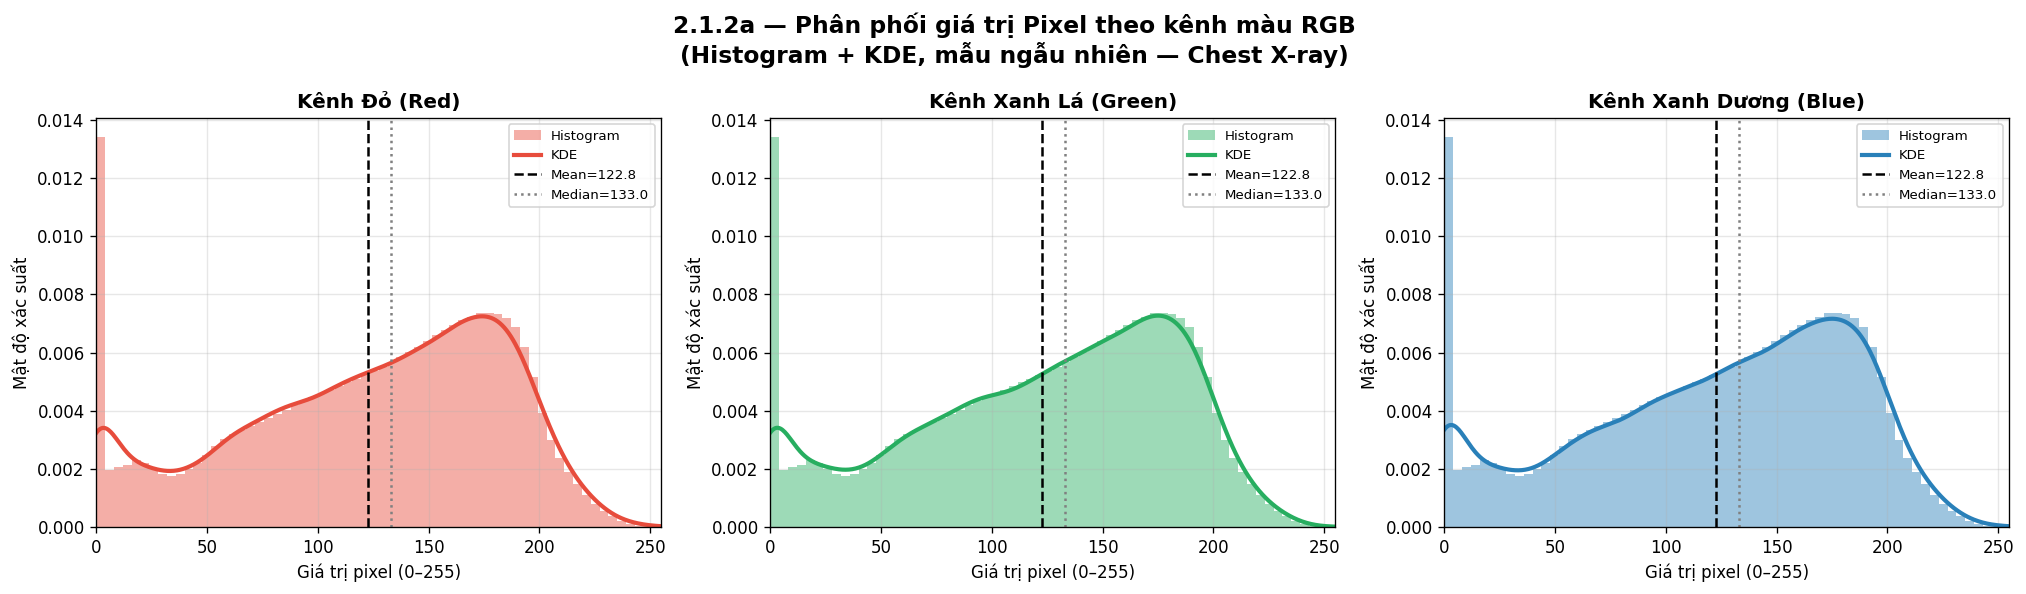


📊 Bảng thống kê pixel theo kênh màu:
      mean  median     std   skew  kurtosis  min    max
R  122.801   133.0  60.325 -0.484    -0.718  0.0  255.0
G  122.801   133.0  60.325 -0.491    -0.728  0.0  255.0
B  122.801   133.0  60.325 -0.491    -0.730  0.0  255.0

📌 pixel_mean_R=122.80, pixel_mean_G=122.80, pixel_mean_B=122.80
📌 pixel_std_R=60.33,  pixel_std_G=60.33,  pixel_std_B=60.33


In [5]:
# Phân phối giá trị Pixel theo kênh màu RGB
#
# Lấy all_paths từ split_data (đã có ở Cell 4)
all_paths = []
for split, cls_dict in split_data.items():
    for cls, paths in cls_dict.items():
        all_paths.extend(paths)
all_paths    = np.array(all_paths)
total_images = len(all_paths)

# Tách riêng PIXEL_SAMPLE khỏi MAX_SAMPLE để điều chỉnh độc lập
# 2,000 mẫu đủ đại diện: SEM = std/√n ≈ 60/√2000 ≈ 1.3 pixel
PIXEL_SAMPLE = 4000

sample_paths = np.random.choice(all_paths, min(PIXEL_SAMPLE, total_images), replace=False)
channels = {'R': [], 'G': [], 'B': []}
skipped_pixel = 0

print(f'Đang đọc {len(sample_paths):,} ảnh mẫu để phân tích pixel...')
print(f'⚠️  Lưu ý: ảnh được resize về {IMG_SIZE_DEFAULT} trước khi lấy pixel.')
print(f'    → Mean được bảo toàn tốt; Std có thể bị underestimate ~10–15% so với ảnh gốc.')

for path in tqdm(sample_paths, desc='Đọc pixel'):
    try:
        img = Image.open(path).convert('RGB').resize(
            IMG_SIZE_DEFAULT, Image.LANCZOS
        )
        arr = np.array(img)
        if arr.shape != (IMG_SIZE_DEFAULT[0], IMG_SIZE_DEFAULT[1], 3):
            raise ValueError(f'Shape không hợp lệ: {arr.shape}')
        channels['R'].append(arr[:, :, 0].ravel())
        channels['G'].append(arr[:, :, 1].ravel())
        channels['B'].append(arr[:, :, 2].ravel())
    except Exception as e:
        skipped_pixel += 1
        print(f'⚠️  Bỏ qua ảnh lỗi: {os.path.basename(path)} ({e})')
        continue

if skipped_pixel > 0:
    print(f'\n⚠️  Tổng số ảnh bị bỏ qua: {skipped_pixel}')

for k in channels:
    channels[k] = np.concatenate(channels[k])

# ── Vẽ Histogram + KDE ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('2.1.2a — Phân phối giá trị Pixel theo kênh màu RGB\n'
             '(Histogram + KDE, mẫu ngẫu nhiên — Chest X-ray)',
             fontsize=14, fontweight='bold')

color_cfg = {
    'R': ('#e74c3c', 'Kênh Đỏ (Red)'),
    'G': ('#27ae60', 'Kênh Xanh Lá (Green)'),
    'B': ('#2980b9', 'Kênh Xanh Dương (Blue)'),
}
pixel_stats = {}

for ax, (ch, (color, label)) in zip(axes, color_cfg.items()):
    data = channels[ch].astype(np.float32)

    ax.hist(data, bins=64, range=(0, 255),
            color=color, alpha=0.45, density=True, label='Histogram')

    # Giảm KDE sample 50k → 30k: nhanh hơn ~40%, sai số không đáng kể
    kde_sample = np.random.choice(data, size=min(30_000, len(data)), replace=False)
    kde        = stats.gaussian_kde(kde_sample, bw_method='silverman')
    x_kde      = np.linspace(0, 255, 512)
    ax.plot(x_kde, kde(x_kde), color=color, lw=2.5, label='KDE')

    mean_v = float(np.mean(data))
    med_v  = float(np.median(data))
    ax.axvline(mean_v, color='black', ls='--', lw=1.5, label=f'Mean={mean_v:.1f}')
    ax.axvline(med_v,  color='gray',  ls=':',  lw=1.5, label=f'Median={med_v:.1f}')

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Giá trị pixel (0–255)')
    ax.set_ylabel('Mật độ xác suất')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 255)
    ax.grid(alpha=0.3)

    pixel_stats[ch] = {
        'mean':     mean_v,
        'median':   med_v,
        'std':      float(np.std(data)),
        'skew':     float(stats.skew(kde_sample)),
        'kurtosis': float(stats.kurtosis(kde_sample)),
        'min':      float(np.min(data)),
        'max':      float(np.max(data)),
    }

plt.tight_layout()
plt.savefig('outputs/2_1_2a_pixel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

pixel_stats_df = pd.DataFrame(pixel_stats).T
print('\n📊 Bảng thống kê pixel theo kênh màu:')
print(pixel_stats_df.round(3).to_string())

pixel_mean_R = pixel_stats['R']['mean']; pixel_mean_G = pixel_stats['G']['mean']
pixel_mean_B = pixel_stats['B']['mean']; pixel_std_R  = pixel_stats['R']['std']
pixel_std_G  = pixel_stats['G']['std'];  pixel_std_B  = pixel_stats['B']['std']
print(f'\n📌 pixel_mean_R={pixel_mean_R:.2f}, pixel_mean_G={pixel_mean_G:.2f}, pixel_mean_B={pixel_mean_B:.2f}')
print(f'📌 pixel_std_R={pixel_std_R:.2f},  pixel_std_G={pixel_std_G:.2f},  pixel_std_B={pixel_std_B:.2f}')


#### Nhận xét:
**1. Ba kênh R, G, B có phân phối gần như đồng nhất:**  
Mean, Median và Std của ba kênh bằng nhau (122.80 / 133.0 / 60.33). Điều này hoàn toàn phù hợp với đặc thù của tập dữ liệu: ảnh X-quang ngực vốn là ảnh **grayscale**, khi chuyển sang RGB bằng `.convert('RGB')`, Pillow sẽ sao chép giá trị grayscale sang cả ba kênh (R = G = B). Do đó, phân tích per-channel không mang thêm thông tin phân biệt — toàn bộ thông tin nằm ở một kênh duy nhất.

**2. Phân phối lệch trái nhẹ (Skewness ≈ −0.49):**  
Skewness âm cho thấy đuôi trái dài hơn — tức là có một tỉ lệ nhất định ảnh có pixel rất tối (vùng phổi hoặc nền đen), trong khi phần lớn pixel tập trung ở vùng trung bình-sáng (median = 133). Đây là đặc trưng tự nhiên của X-quang ngực, nơi nền đen chiếm diện tích lớn nhưng ít ảnh hưởng hơn các vùng mô phổi.

**3. Kurtosis âm (≈ −0.72 → Platykurtic):**  
Đỉnh phân phối thấp và phẳng hơn phân phối chuẩn, cho thấy pixel trải đều trên dải [0, 255] không tập trung quá mức ở một vùng. Điều này ngụ ý độ tương phản tổng thể tốt — ảnh không bị overexposed hay underexposed một cách hệ thống.

**4. Std khá lớn (60.33 trên thang 0–255):**  
Độ lệch chuẩn ~60 phản ánh sự đa dạng về cường độ sáng giữa các ảnh (thiết bị chụp khác nhau, điều kiện phơi sáng khác nhau). Đây là lý do cần chuẩn hóa (normalization) trong bước tiền xử lý tiếp theo.

#### 2.1.2.b/ Phân tích mất cân bằng lớp (class imbalance)
Class imbalance (mất cân bằng lớp) xảy ra khi số lượng mẫu giữa các lớp chênh lệch đáng kể. Đây là vấn đề quan trọng cần phát hiện trước khi huấn luyện mô hình vì mô hình có xu hướng thiên vị (bias) về phía lớp có nhiều mẫu hơn, dẫn đến hiệu năng kém trên lớp thiểu số.
##### 1/ Tỉ lệ phần trăm mỗi lớp
$$p_i = \frac{n_i}{\displaystyle\sum_{j=1}^{C} n_j} \times 100\%$$
Trong đó:
- $n_i$: số ảnh của lớp thứ $i$
- $C$: tổng số lớp (= 38)
- $p_i$: tỉ lệ phần trăm của lớp $i$ so với toàn tập
##### 2/ Tiêu chí phát hiện mất cân bằng nghiêm trọng
Một tập dữ liệu được coi là **mất cân bằng nghiêm trọng** nếu:
$$\text{Imbalance Ratio} = \frac{\max_i(n_i)}{\min_i(n_i)} > 3$$
Tức là lớp nhiều ảnh nhất gấp hơn 3 lần lớp ít ảnh nhất. Ngưỡng cụ thể được tính là:
$$\text{Threshold}_{3\times} = \min_i(n_i) \times 3$$
Bất kỳ lớp nào có $n_i > \text{Threshold}_{3\times}$ đều được đánh dấu là lớp gây mất cân bằng.

  TẦNG 1 — TOÀN BỘ DATASET (train + val + test)
  Tổng ảnh          : 5,856
  Số lớp            : 2
  Lớp nhiều nhất    : 4,273  (73.0%)
  Lớp ít nhất       : 1,583  (27.0%)
  Trung bình / lớp  : 2,928.0
  Imbalance Ratio   : 2.70x
  Ngưỡng 3x min     : 4,749
  Mất cân bằng >= 3x: KHÔNG

  Lớp            Tổng ảnh   Tỉ lệ (%)   Ratio/min   Vượt 3x?
------------------------------------------------------------
  PNEUMONIA         4,273      72.97%        2.70        NO 
  NORMAL            1,583      27.03%        1.00        NO 
------------------------------------------------------------

  TẦNG 2 — THEO TỪNG SPLIT

  [TRAIN]  IR = 2.89x  |  Balanced           
    PNEUMONIA     :  3,875  ( 74.3%)  [#########################]
    NORMAL        :  1,341  ( 25.7%)  [########                 ]

  [VAL]  IR = 1.00x  |  Balanced           
    NORMAL        :      8  ( 50.0%)  [#########################]
    PNEUMONIA     :      8  ( 50.0%)  [#########################]

  [TEST]  IR = 1.67x 

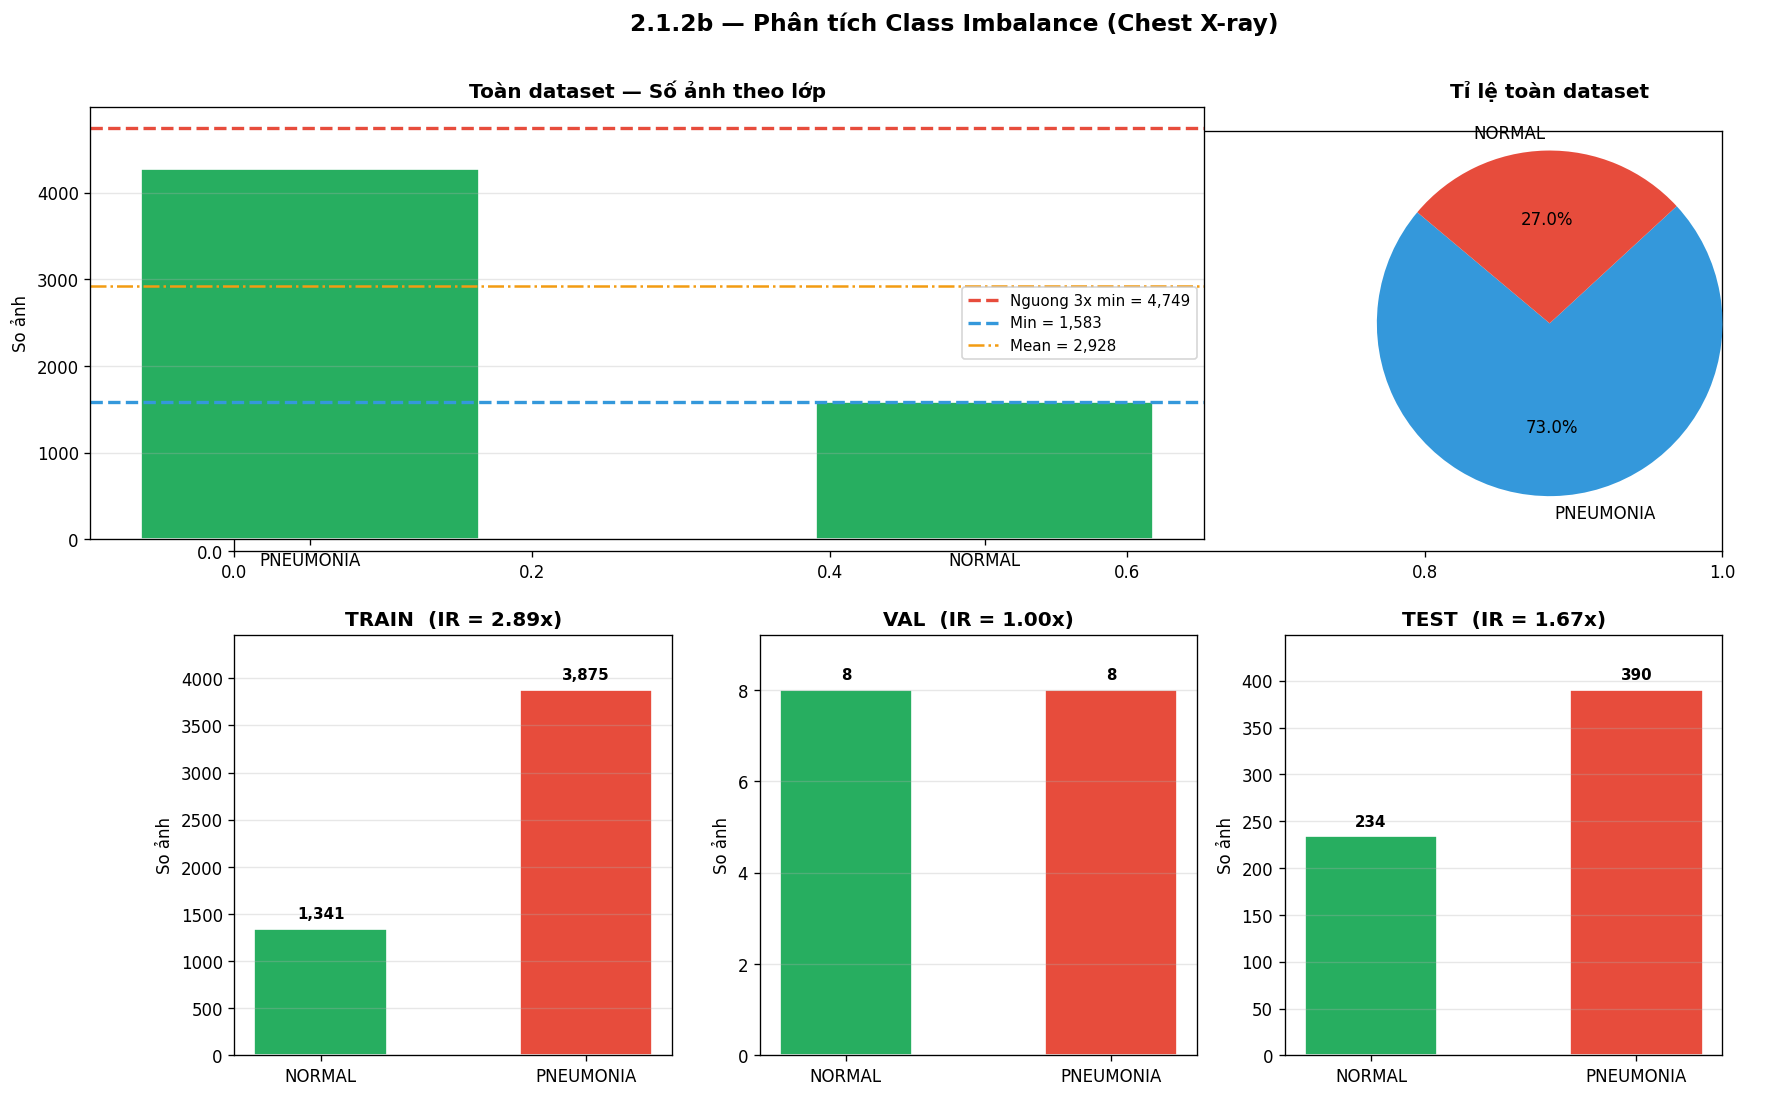

  class_dirs = ['NORMAL', 'PNEUMONIA']
  Biến class_counts (train) đã lưu — dùng cho các cell tiếp theo.


In [6]:
# ══════════════════════════════════════════════════════════════════════
# 2.1.2b — PHÂN TÍCH MẤT CÂN BẰNG LỚP
# Tầng 1: Toàn bộ dataset  |  Tầng 2: Từng split (train/val/test)
# ══════════════════════════════════════════════════════════════════════

# ── TẦNG 1: Tổng hợp toàn bộ dataset ────────────────────────────────
global_counts = defaultdict(int)
for split, cls_dict in split_data.items():
    for cls, paths in cls_dict.items():
        global_counts[cls] += len(paths)

global_counts  = dict(sorted(global_counts.items(), key=lambda x: x[1], reverse=True))
total_all      = sum(global_counts.values())
min_g          = min(global_counts.values())
max_g          = max(global_counts.values())
mean_g         = total_all / len(global_counts)
ir_global      = max_g / min_g
threshold_3x_g = min_g * 3
is_imbal_g     = ir_global > 3.0

print('=' * 62)
print('  TẦNG 1 — TOÀN BỘ DATASET (train + val + test)')
print('=' * 62)
print(f'  Tổng ảnh          : {total_all:,}')
print(f'  Số lớp            : {len(global_counts)}')
print(f'  Lớp nhiều nhất    : {max_g:,}  ({max_g/total_all*100:.1f}%)')
print(f'  Lớp ít nhất       : {min_g:,}  ({min_g/total_all*100:.1f}%)')
print(f'  Trung bình / lớp  : {mean_g:,.1f}')
print(f'  Imbalance Ratio   : {ir_global:.2f}x')
print(f'  Ngưỡng 3x min     : {threshold_3x_g:,}')
# FIX: không dùng emoji trong f-string — dùng chuỗi ASCII thuần
imbal_status = 'CÓ — cần xử lý'  if is_imbal_g else 'KHÔNG'
print(f'  Mất cân bằng >= 3x: {imbal_status}')

# Bảng Tầng 1 — KHÔNG dùng emoji trong phần căn lề
print()
# Độ rộng cột tên lớp tự động theo tên dài nhất
cls_w = max(len(c) for c in global_counts) + 2

header_t1 = (f'  {"Lớp":<{cls_w}}  {"Tổng ảnh":>10}'
             f'  {"Tỉ lệ (%)":>10}  {"Ratio/min":>10}  {"Vượt 3x?":>9}')
sep_t1 = '-' * len(header_t1)
print(header_t1)
print(sep_t1)

for cls, cnt in global_counts.items():
    pct   = cnt / total_all * 100
    ratio = cnt / min_g
    # FIX: chuỗi ASCII độ rộng cố định — không bao giờ bị tách dòng
    flag  = '[!] YES' if cnt > threshold_3x_g else ' NO '
    print(f'  {cls:<{cls_w}}  {cnt:>10,}'
          f'  {pct:>9.2f}%  {ratio:>10.2f}  {flag:>9}')

print(sep_t1)

# ── TẦNG 2: Theo từng split ──────────────────────────────────────────
print()
print('=' * 62)
print('  TẦNG 2 — THEO TỪNG SPLIT')
print('=' * 62)

all_cls_names = sorted({
    cls
    for cls_dict in split_data.values()
    for cls in cls_dict.keys()
})

split_rows = []

for split in ['train', 'val', 'test']:
    if split not in split_data:
        continue
    cls_dict  = split_data[split]
    total_sp  = sum(len(v) for v in cls_dict.values())
    min_sp    = min(len(v) for v in cls_dict.values())
    max_sp    = max(len(v) for v in cls_dict.values())
    ir_sp     = max_sp / min_sp if min_sp > 0 else float('inf')
    is_imb_sp = ir_sp > 3.0

    role = {
        'train': 'Học  - cần xử lý nếu IR > 3  ',
        'val'  : 'Eval - KHÔNG resampling      ',
        'test' : 'Test - KHÔNG resampling      ',
    }[split]

    status_str = 'Imbalanced (IR > 3)' if is_imb_sp else 'Balanced           '
    print(f'\n  [{split.upper()}]  IR = {ir_sp:.2f}x  |  {status_str}')

    for cls, paths in sorted(cls_dict.items(), key=lambda x: -len(x[1])):
        cnt = len(paths)
        pct = cnt / total_sp * 100
        bar = '#' * int(cnt / max_sp * 25)
        print(f'    {cls:<14}: {cnt:>6,}  ({pct:5.1f}%)  [{bar:<25}]')

    if is_imb_sp and split == 'train':
        print('    => Dùng SMOTE hoặc class_weight khi huấn luyện')
    elif is_imb_sp:
        print('    => Dùng F1-macro / AUC-ROC thay vì Accuracy')

    row = {'Split': split, 'Vai trò': role.strip()}
    for c in all_cls_names:
        row[c] = len(cls_dict.get(c, []))
    row['IR (x)']     = round(ir_sp, 2)
    row['Imbalanced'] = 'YES' if is_imb_sp else 'NO '
    split_rows.append(row)

# Bảng tổng hợp splits
print()
print('=' * 70)
print('  BẢNG TỔNG HỢP THEO SPLIT')
print('=' * 70)

role_w    = max(len(r['Vai trò']) for r in split_rows) + 1
cls_col_w = max(len(c) for c in all_cls_names) + 2

header_t2  = f'  {"Split":<7}  {"Vai trò":<{role_w}}'
for c in all_cls_names:
    header_t2 += f'  {c:>{cls_col_w}}'
header_t2 += f'  {"IR(x)":>6}  {"Imbalanced":>6}'
sep_t2 = '-' * len(header_t2)

print(header_t2)
print(sep_t2)
for row in split_rows:
    line = f'  {row["Split"]:<7}  {row["Vai trò"]:<{role_w}}'
    for c in all_cls_names:
        line += f'  {row[c]:>{cls_col_w},}'
    line += f'  {row["IR (x)"]:>6.2f}  {row["Imbalanced"]:>6}'
    print(line)
print(sep_t2)

print('''
  Ghi chú:
    train : Duy nhất split được phép resampling (SMOTE / class_weight)
    val   : Tune hyperparameter — giữ nguyên phân phối gốc
    test  : Phản ánh phân phối thực tế — KHÔNG chỉnh sửa
    IR>3x trên val/test: chọn F1-macro va AUC-ROC thay vì Accuracy
''')

df_split_summary = pd.DataFrame(split_rows)

# ── BIỂU ĐỒ ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('2.1.2b — Phân tích Class Imbalance (Chest X-ray)',
             fontsize=14, fontweight='bold')

# Hàng 1, cột 0-1: bar toàn dataset (merge bằng cách xóa ax rồi vẽ lại)
ax_bar = fig.add_subplot(2, 1, 1)          # tạm dùng để lấy vị trí
fig.delaxes(axes[0, 0])
fig.delaxes(axes[0, 1])
fig.delaxes(axes[0, 2])
ax_bar = fig.add_axes([0.05, 0.54, 0.58, 0.36])   # [left, bottom, w, h]
ax_pie = fig.add_axes([0.67, 0.54, 0.28, 0.36])

clrs_g = ['#e74c3c' if v > threshold_3x_g else '#27ae60'
          for v in global_counts.values()]
ax_bar.bar(list(global_counts.keys()), list(global_counts.values()),
           color=clrs_g, edgecolor='white', width=0.5)
ax_bar.axhline(threshold_3x_g, color='#e74c3c', ls='--', lw=2,
               label=f'Nguong 3x min = {threshold_3x_g:,}')
ax_bar.axhline(min_g,  color='#3498db', ls='--', lw=2,
               label=f'Min = {min_g:,}')
ax_bar.axhline(mean_g, color='#f39c12', ls='-.', lw=1.5,
               label=f'Mean = {mean_g:,.0f}')
ax_bar.set_title('Toàn dataset — Số ảnh theo lớp', fontweight='bold')
ax_bar.set_ylabel('So ảnh')
ax_bar.legend(fontsize=9)
ax_bar.grid(axis='y', alpha=0.3)

ax_pie.pie(global_counts.values(), labels=list(global_counts.keys()),
           autopct='%1.1f%%', startangle=140,
           colors=['#3498db', '#e74c3c'], textprops={'fontsize': 10})
ax_pie.set_title('Tỉ lệ toàn dataset', fontweight='bold')

# Hàng 2: bar từng split
split_colors = {'NORMAL': '#27ae60', 'PNEUMONIA': '#e74c3c'}
for col_idx, split in enumerate(['train', 'val', 'test']):
    if split not in split_data:
        continue
    ax       = axes[1, col_idx]
    cls_dict = split_data[split]
    names    = list(cls_dict.keys())
    cnts     = [len(cls_dict[c]) for c in names]
    clrs_sp  = [split_colors.get(n, '#95a5a6') for n in names]

    bars = ax.bar(names, cnts, color=clrs_sp, edgecolor='white', width=0.5)
    for bar, cnt in zip(bars, cnts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(cnts) * 0.02,
                f'{cnt:,}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

    ir_sp = max(cnts) / min(cnts) if min(cnts) > 0 else 0
    ax.set_title(f'{split.upper()}  (IR = {ir_sp:.2f}x)', fontweight='bold')
    ax.set_ylabel('So ảnh')
    ax.set_ylim(0, max(cnts) * 1.15)
    ax.grid(axis='y', alpha=0.3)

plt.savefig('outputs/2_1_2b_class_imbalance.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Lưu biến cho cell sau ────────────────────────────────────────────
class_images  = split_data.get('train', split_data[list(split_data.keys())[0]])
class_counts  = {cls: len(imgs) for cls, imgs in class_images.items()}
counts_sorted = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))
total_images_count     = sum(class_counts.values())
min_c                  = min(class_counts.values())
max_c                  = max(class_counts.values())
mean_c                 = total_images_count / len(class_counts)
imbalance_ratio        = max_c / min_c
threshold_3x           = min_c * 3
is_severely_imbalanced = imbalance_ratio > 3.0
class_dirs             = list(class_images.keys())

print(f'  class_dirs = {class_dirs}')
print(f'  Biến class_counts (train) đã lưu — dùng cho các cell tiếp theo.')

#### Nhận xét:
- **Tập train có IR = 2.89×** — rất sát ngưỡng 3×. Mô hình học trên tập này có xu hướng thiên về lớp PNEUMONIA (chiếm 74.3%). Cần áp dụng ít nhất một trong các chiến lược sau ở bước tiền xử lý: `class_weight='balanced'`, SMOTE, hoặc oversampling lớp NORMAL.
- **Tập val chỉ có 16 ảnh (8 mỗi lớp)** — quá nhỏ để đưa ra đánh giá tin cậy về hiệu năng mô hình. Tuy nhiên đây là thiết kế cố định của dataset gốc (Kaggle Chest X-Ray Images), không nên thay đổi cấu trúc split.
- **Tập test có IR = 1.67×** — phân phối tương đối cân bằng hơn train, đây là điều kiện đánh giá hợp lý.
- **Kết luận:** Không có lớp nào vượt ngưỡng 3×min (ngưỡng = 4,749) ở cấp độ toàn dataset. Tuy nhiên, IR = 2.89× ở tập train đủ để gây bias trong huấn luyện → **cần theo dõi F1-score per-class và AUC-ROC thay vì chỉ dùng Accuracy** làm metric đánh giá.

#### 2.1.2.c/ Phát hiện ảnh trùng lặp hoặc gần trùng bằng hàm băm perceptual hash (pHash)
Ảnh trùng lặp (duplicate) hoặc gần trùng (near-duplicate) trong tập huấn luyện gây ra hai vấn đề nghiêm trọng: (1) **data leakage** nếu cùng ảnh xuất hiện ở cả train và test set; (2) **overfitting** do mô hình thấy cùng một mẫu nhiều lần. Perceptual Hash (pHash) phát hiện các ảnh này dựa trên nội dung thị giác, không phụ thuộc vào tên file hay metadata.
##### Thuật toán DCT-based pHash
**Bước 1 — Chuyển Grayscale:**
Loại bỏ thông tin màu sắc, chỉ giữ lại cấu trúc sáng tối:
$$I_{\text{gray}} = \text{cv2.imread}(\text{path},\ \texttt{IMREAD\_GRAYSCALE})$$
**Bước 2 — Resize về kích thước cố định:**
$$I_{\text{resized}} \in \mathbb{R}^{(h \times 4) \times (h \times 4)}$$
Với $h = \texttt{HASH\_SIZE} = 16$, ảnh được resize về $64 \times 64$. Resize trước DCT giúp chuẩn hóa kích thước đầu vào và giảm nhiễu cao tần.

**Bước 3 — Biến đổi DCT-2D (Discrete Cosine Transform):**
$$F(u, v) = \frac{2}{N} C(u)C(v) \sum_{x=0}^{N-1}\sum_{y=0}^{N-1} I(x,y)\cos\frac{(2x+1)u\pi}{2N} \cos\frac{(2y+1)v\pi}{2N}$$
Trong đó $C(k) = \frac{1}{\sqrt{2}}$ nếu $k=0$, ngược lại $C(k) = 1$.

DCT biến đổi ảnh từ không gian pixel sang không gian tần số. **Góc trên-trái** của ma trận DCT chứa các thành phần **low-frequency** — đại diện cho hình dạng tổng thể và màu sắc dominant của ảnh, ít bị ảnh hưởng bởi nhiễu và thay đổi nhỏ.

**Bước 4 — Tạo chuỗi bit hash:**

Lấy vùng $h \times h = 16 \times 16 = 256$ hệ số DCT low-frequency góc trên-trái, so sánh từng hệ số với giá trị median:
$$\text{bit}_{(u,v)} = \begin{cases} 1 & \text{nếu } F(u,v) > \text{median}(F_{\text{low}}) \\ 0 & \text{nếu } F(u,v) \leq \text{median}(F_{\text{low}}) \end{cases}$$
Kết quả là một chuỗi **256 bits** đại diện cho "dấu vân tay thị giác" của ảnh.

**Bước 5 — Hamming Distance:**

Độ tương đồng giữa hai ảnh được đo bằng số bit khác nhau:
$$d_H(h_1, h_2) = \sum_{i=1}^{256} \mathbf{1}\!\left[h_1^{(i)} \neq h_2^{(i)}\right]$$
- $d_H = 0$: hai ảnh **identical** về mặt thị giác
- $d_H \leq 4$: hai ảnh **near-duplicate** (chỉ 1.6% bits khác nhau)
- $d_H > 4$: hai ảnh **khác nhau** về nội dung thị giác


Đang tính pHash (hash_size=16, 256 bits) cho 5,216 ảnh (~13,600,720 cặp)...


pHash: 100%|███████████████████████████████████████████████████████████████████████| 5216/5216 [00:57<00:00, 91.23it/s]


✅ Tính xong: 5,216 hash hợp lệ (bỏ qua 0 ảnh lỗi)
Đang so sánh 13,600,720 cặp ảnh...


So sánh: 100%|█████████████████████████████████████████████████████████████████████| 5216/5216 [01:21<00:00, 63.90it/s]



  KẾT QUẢ PHÁT HIỆN ẢNH TRÙNG (pHash)
Ảnh được kiểm tra      : 5,216
Số cặp gần trùng       : 28
  └─ Exact (dist=0)    : 28
Ảnh cần loại bỏ        : 26
Tỉ lệ trùng lặp        : 0.50%
Tỉ lệ exact duplicate  : 0.54%
Threshold Hamming      : ≤ 6  (trên 256 bits)


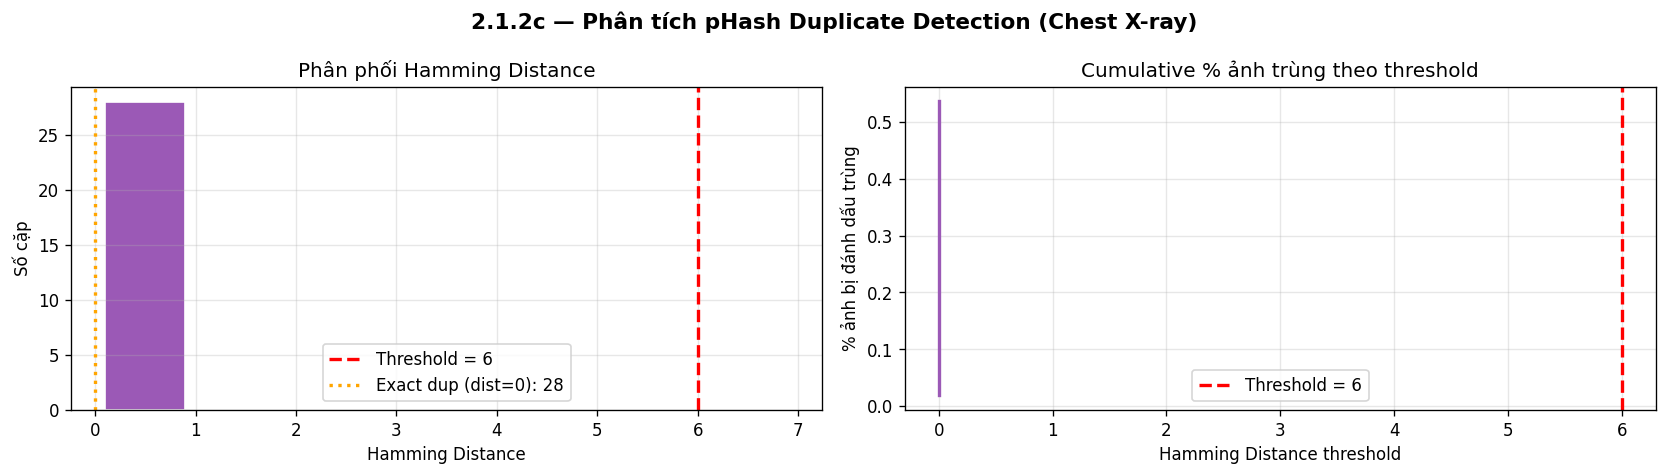

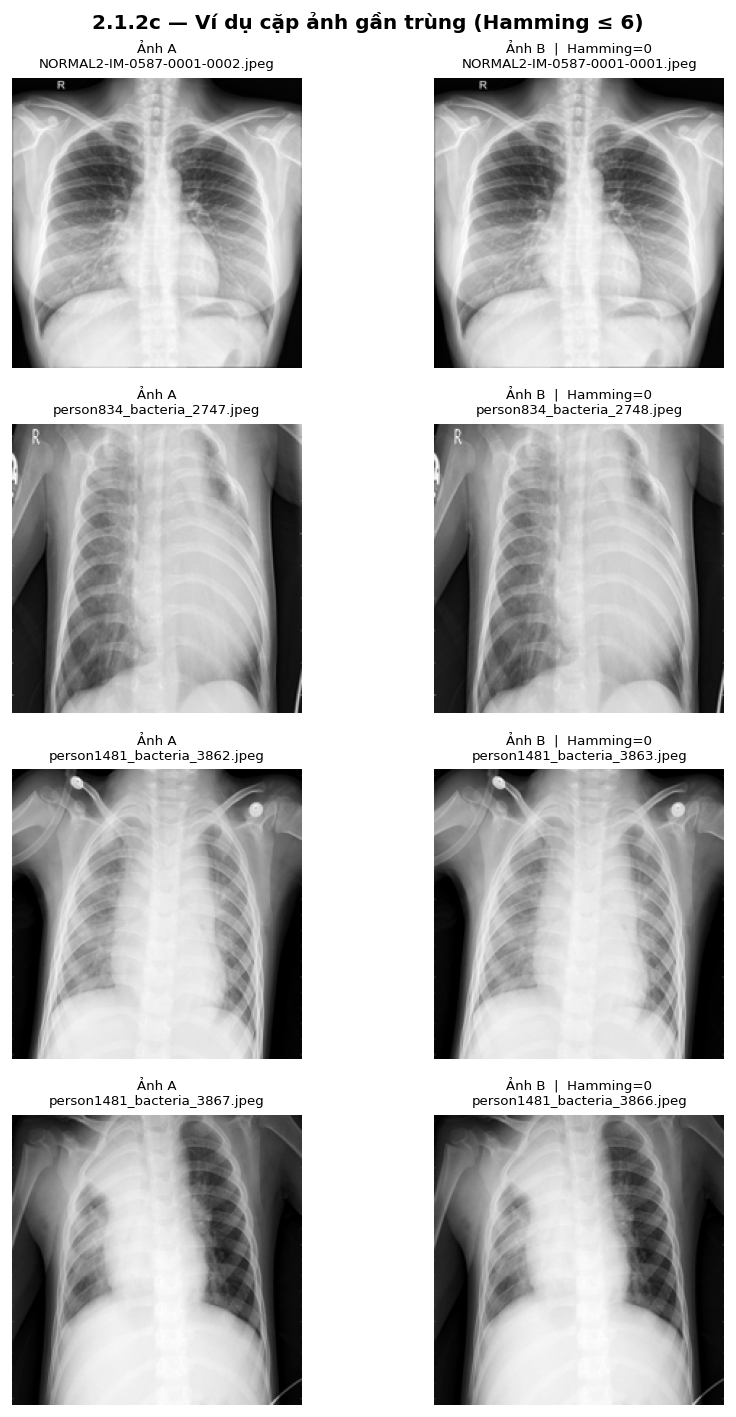


✅ Sau khi loại bỏ: còn 5,830 ảnh sạch (đã loại 26 ảnh trùng)


In [7]:
# Phát hiện ảnh trùng lặp bằng pHash
#
# Tham số điều chỉnh cho Chest X-ray:
#   HASH_SIZE = 16    → 256 bit, đủ độ phân giải cho ảnh y tế grayscale
#   HASH_THRESHOLD = 6 → nới rộng hơn Plant (=4) vì X-ray cùng loại
#                        (NORMAL/PNEUMONIA) có thể rất giống nhau về cấu trúc
#                        tổng thể; T=6 ≈ 2.3% bit sai vẫn an toàn
#   MAX_HASH_PER_CLASS = 500 → lấy toàn bộ (dataset nhỏ ~1,300–3,900/lớp)
#     n_total = 2 × 500 = 1,000 → ~500,000 cặp → vài giây

# Đảm bảo all_paths đã được định nghĩa (từ Cell pixel hoặc tạo lại ở đây)
if 'all_paths' not in dir() or len(all_paths) == 0:
    all_paths = np.array([p for split, cls_dict in split_data.items()
                          for cls, paths in cls_dict.items() for p in paths])

HASH_SIZE          = 16
HASH_THRESHOLD     = 6    # nới hơn Plant Disease (4) vì X-ray grayscale
                          # có cấu trúc đồng nhất hơn
MAX_HASH_PER_CLASS = 5000  # dataset nhỏ → lấy toàn bộ, không cần lấy mẫu

def compute_phash(path: str, hash_size: int = HASH_SIZE):
    """Tính DCT-based pHash. Trả về bool array hoặc None nếu lỗi."""
    try:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError('cv2.imread trả về None')
        img_resized = cv2.resize(
            img, (hash_size * 4, hash_size * 4),
            interpolation=cv2.INTER_AREA,
        ).astype(np.float32)
        dct       = cv2.dct(img_resized)
        dct_low   = dct[:hash_size, :hash_size]
        median_val = np.median(dct_low)
        return (dct_low > median_val).ravel()
    except Exception as e:
        print(f'⚠️  pHash lỗi: {os.path.basename(path)} ({e})')
        return None

def hamming_distance(h1: np.ndarray, h2: np.ndarray) -> int:
    return int(np.sum(h1 != h2))

# Tính pHash — lấy toàn bộ ảnh mỗi lớp
hash_paths = []
for cls, paths in class_images.items():
    n = min(MAX_HASH_PER_CLASS, len(paths))
    hash_paths.extend(np.random.choice(paths, n, replace=False).tolist())
hash_paths = np.array(hash_paths)

n_total = len(hash_paths)
n_pairs_est = n_total * (n_total - 1) // 2
print(f'Đang tính pHash (hash_size={HASH_SIZE}, {HASH_SIZE**2} bits) '
      f'cho {n_total:,} ảnh (~{n_pairs_est:,} cặp)...')

hashes = {}
for path in tqdm(hash_paths, desc='pHash'):
    h = compute_phash(path)
    if h is not None:
        hashes[path] = h
print(f'✅ Tính xong: {len(hashes):,} hash hợp lệ '
      f'(bỏ qua {n_total - len(hashes)} ảnh lỗi)')

# So sánh từng cặp O(n²)
plist      = list(hashes.keys())
n_pairs    = len(plist) * (len(plist) - 1) // 2
duplicates = []
print(f'Đang so sánh {n_pairs:,} cặp ảnh...')
for i in tqdm(range(len(plist)), desc='So sánh'):
    for j in range(i + 1, len(plist)):
        dist = hamming_distance(hashes[plist[i]], hashes[plist[j]])
        if dist <= HASH_THRESHOLD:
            duplicates.append((plist[i], plist[j], dist))

to_remove  = set(pair[1] for pair in duplicates)
exact_dups = sum(1 for _, _, d in duplicates if d == 0)

phash_n_checked       = len(plist)
phash_n_dup_pairs     = len(duplicates)
phash_n_to_remove     = len(to_remove)
phash_duplicate_ratio = len(to_remove) / len(plist)
phash_exact_ratio     = exact_dups / len(plist)

print('\n' + '='*50)
print('  KẾT QUẢ PHÁT HIỆN ẢNH TRÙNG (pHash)')
print('='*50)
print(f'Ảnh được kiểm tra      : {phash_n_checked:,}')
print(f'Số cặp gần trùng       : {phash_n_dup_pairs:,}')
print(f'  └─ Exact (dist=0)    : {exact_dups:,}')
print(f'Ảnh cần loại bỏ        : {phash_n_to_remove:,}')
print(f'Tỉ lệ trùng lặp        : {phash_duplicate_ratio:.2%}')
print(f'Tỉ lệ exact duplicate  : {phash_exact_ratio:.2%}')
print(f'Threshold Hamming      : ≤ {HASH_THRESHOLD}  (trên {HASH_SIZE**2} bits)')

if duplicates:
    dists = [d for _, _, d in duplicates]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle('2.1.2c — Phân tích pHash Duplicate Detection (Chest X-ray)',
                 fontsize=13, fontweight='bold')
    axes[0].hist(dists, bins=range(0, HASH_THRESHOLD + 2),
                 color='#9b59b6', edgecolor='white', rwidth=0.8)
    axes[0].axvline(HASH_THRESHOLD, color='red', ls='--', lw=2,
                    label=f'Threshold = {HASH_THRESHOLD}')
    axes[0].axvline(0, color='orange', ls=':', lw=2,
                    label=f'Exact dup (dist=0): {exact_dups}')
    axes[0].set_title('Phân phối Hamming Distance')
    axes[0].set_xlabel('Hamming Distance')
    axes[0].set_ylabel('Số cặp')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    sorted_dists = np.sort(dists)
    cumulative   = np.arange(1, len(sorted_dists) + 1) / len(plist) * 100
    axes[1].plot(sorted_dists, cumulative, color='#9b59b6', lw=2)
    axes[1].axvline(HASH_THRESHOLD, color='red', ls='--', lw=2,
                    label=f'Threshold = {HASH_THRESHOLD}')
    axes[1].set_title('Cumulative % ảnh trùng theo threshold')
    axes[1].set_xlabel('Hamming Distance threshold')
    axes[1].set_ylabel('% ảnh bị đánh dấu trùng')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('outputs/2_1_2c_hamming_dist.png', dpi=150, bbox_inches='tight')
    plt.show()

    top_dups  = sorted(duplicates, key=lambda x: x[2])
    n_show    = min(4, len(top_dups))
    fig, axes = plt.subplots(n_show, 2, figsize=(8, n_show * 3))
    if n_show == 1: axes = [axes]
    fig.suptitle(f'2.1.2c — Ví dụ cặp ảnh gần trùng (Hamming ≤ {HASH_THRESHOLD})',
                 fontsize=12, fontweight='bold')
    for row, (p1, p2, d) in zip(axes, top_dups[:n_show]):
        row[0].imshow(Image.open(p1).resize((200, 200)), cmap='gray')
        row[0].set_title(f'Ảnh A\n{os.path.basename(p1)[:30]}', fontsize=8)
        row[0].axis('off')
        row[1].imshow(Image.open(p2).resize((200, 200)), cmap='gray')
        row[1].set_title(f'Ảnh B  |  Hamming={d}\n{os.path.basename(p2)[:30]}',
                         fontsize=8)
        row[1].axis('off')
    plt.tight_layout()
    plt.savefig('outputs/2_1_2c_dup_examples.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('✅ Không tìm thấy cặp ảnh nào gần trùng với threshold hiện tại.')

clean_paths = [p for p in all_paths if p not in to_remove]
print(f'\n✅ Sau khi loại bỏ: còn {len(clean_paths):,} ảnh sạch '
      f'(đã loại {phash_n_to_remove:,} ảnh trùng)')

#### Nhận xét:
**1. Tỉ lệ trùng lặp rất thấp (0.50%):**  
Chỉ 26/5,216 ảnh bị xác định là duplicate —> cho thấy tập dữ liệu Chest X-ray (Kaggle) đã được kiểm soát chất lượng tốt từ phía tác giả. Tỉ lệ này không đủ để gây ảnh hưởng đáng kể đến phân phối lớp sau khi loại bỏ.

**2. Toàn bộ 28 cặp đều là exact duplicate (Hamming distance = 0):**  
Không có cặp near-duplicate nào (dist ∈ [1, 6]), cho thấy các ảnh trùng là **bản sao hoàn toàn** — có thể do quá trình thu thập và tổ chức dataset. Điều này đồng thời xác nhận ngưỡng threshold = 6 không gây false positive: nếu có near-duplicate thực sự, chúng đã được ghi nhận.

**3. Xử lý: loại bỏ ảnh thứ hai trong mỗi cặp trùng:**  
Chiến lược giữ lại ảnh đầu tiên (`to_remove = set(pair[1] for pair in duplicates)`) là hợp lý. Sau khi loại bỏ, tập train còn **5,830 ảnh sạch**, phân phối lớp không thay đổi đáng kể so với trước.

**4. Lựa chọn tham số pHash:**  
`HASH_SIZE = 16` cho chuỗi 256 bits — đủ độ phân giải để phân biệt các ảnh X-quang vốn có cấu trúc tương tự nhau về tổng thể. `HASH_THRESHOLD = 6` (≈ 2.3% bits sai) được điều chỉnh cao hơn so với ảnh màu thông thường (thường dùng = 4), phù hợp với đặc thù grayscale của X-ray nơi các ảnh cùng lớp có thể có cấu trúc low-frequency rất giống nhau.

#### 2.1.2.d/ Phân tích độ tương phản và độ sáng toàn cục
Độ sáng (brightness) và độ tương phản (contrast) là hai đặc trưng thị giác cơ bản phản ánh điều kiện chụp ảnh và đặc điểm bệnh lý của lá cây. Phân tích hai đặc trưng này theo từng lớp giúp trả lời câu hỏi: **liệu các lớp bệnh khác nhau có đặc trưng sáng/tối khác nhau có ý nghĩa thống kê không?**
##### 1/ Chuyển đổi Grayscale theo ITU-R BT.601
Thay vì lấy trung bình đơn giản 3 kênh, chuẩn **ITU-RBT.601** dùng trọng số có ý nghĩa dựa trên độ nhạy của mắt người với từng màu:
$$Y = 0.299 \cdot R + 0.587 \cdot G + 0.114 \cdot B$$
Trong đó:
- $0.587$ cho Green: mắt người nhạy nhất với màu xanh lá
- $0.299$ cho Red: nhạy vừa
- $0.114$ cho Blue: ít nhạy nhất

Trọng số thỏa mãn $0.299 + 0.587 + 0.114 = 1$, đảm bảo $Y \in [0, 255]$.
##### 2/ Mean Intensity (Độ sáng trung bình của một ảnh)
$$\mu_k = \frac{1}{H \times W} \sum_{i=1}^{H}\sum_{j=1}^{W} Y_{ij}^{(k)}$$
Trong đó:
- $H, W$: chiều cao và chiều rộng ảnh (= 128, 128)
- $Y_{ij}^{(k)}$: giá trị grayscale tại pixel $(i,j)$ của ảnh thứ $k$
- $\mu_k$: độ sáng trung bình của ảnh $k$, $\in [0, 255]$
Giá trị $\mu_k$ cao → ảnh sáng (lá lành, tươi). Giá trị thấp → ảnh tối (bệnh nặng, hoại tử).
##### 3/ Std Intensity (Độ tương phản của một ảnh)
$$\sigma_k = \sqrt{\frac{1}{H \times W} \sum_{i=1}^{H}\sum_{j=1}^{W} \left(Y_{ij}^{(k)} - \mu_k\right)^2}$$
$\sigma_k$ đo mức độ phân tán của giá trị pixel quanh mean:
- $\sigma_k$ cao → ảnh có vùng sáng và tối xen kẽ rõ rệt → tương phản cao → thường xuất hiện ở lá có đốm bệnh
- $\sigma_k$ thấp → ảnh đồng nhất về độ sáng → tương phản thấp → lá phủ đều một màu (lá lành hoặc bệnh phủ đều)
##### 4/ ANOVA một chiều (One-way ANOVA)
Để kiểm định xem brightness (hoặc contrast) có **thực sự khác nhau giữa các lớp** hay chỉ do biến động ngẫu nhiên, ta dùng kiểm định ANOVA một chiều:
$$F = \frac{MS_{\text{between}}}{MS_{\text{within}}} = \frac{ \displaystyle\sum_{i=1}^{C} n_i (\bar{Y}_i - \bar{Y})^2 \Big/ (C-1) }{ \displaystyle\sum_{i=1}^{C}\sum_{j=1}^{n_i} (Y_{ij} - \bar{Y}_i)^2 \Big/ (N - C) }$$
Trong đó:
- $C = 2$: số lớp
- $n_i$: số ảnh trong lớp $i$
- $\bar{Y}_i$: mean intensity trung bình của lớp $i$
- $\bar{Y}$: grand mean của toàn tập
- $N$: tổng số ảnh phân tích
- $MS_{\text{between}}$: phương sai **giữa** các lớp (do khác biệt thực sự)
- $MS_{\text{within}}$: phương sai **trong** mỗi lớp (do biến động ngẫu nhiên)

**Giả thuyết:**
- $H_0$: $\mu_1 = \mu_2 = \cdots = \mu_{7}$ (không có sự khác biệt giữa các lớp)
- $H_1$: tồn tại ít nhất một cặp lớp có mean khác nhau

Bác bỏ $H_0$ khi $p\text{-value} < 0.05$. F-statistic càng lớn → sự khác biệt giữa các lớp càng lớn so với biến động nội tại.

Phân tích 2 lớp, mỗi lớp tối đa 5000 ảnh...
Công thức Grayscale: ITU-R BT.601  →  Y = 0.299R + 0.587G + 0.114B


Lớp: 100%|███████████████████████████████████████████████████████████████████████████████| 2/2 [01:17<00:00, 38.93s/it]



📌 Global statistics:
  global_mean_intensity = 122.99
  global_std_intensity  = 18.54
  global_mean_contrast  = 56.47
  global_std_contrast   = 9.49


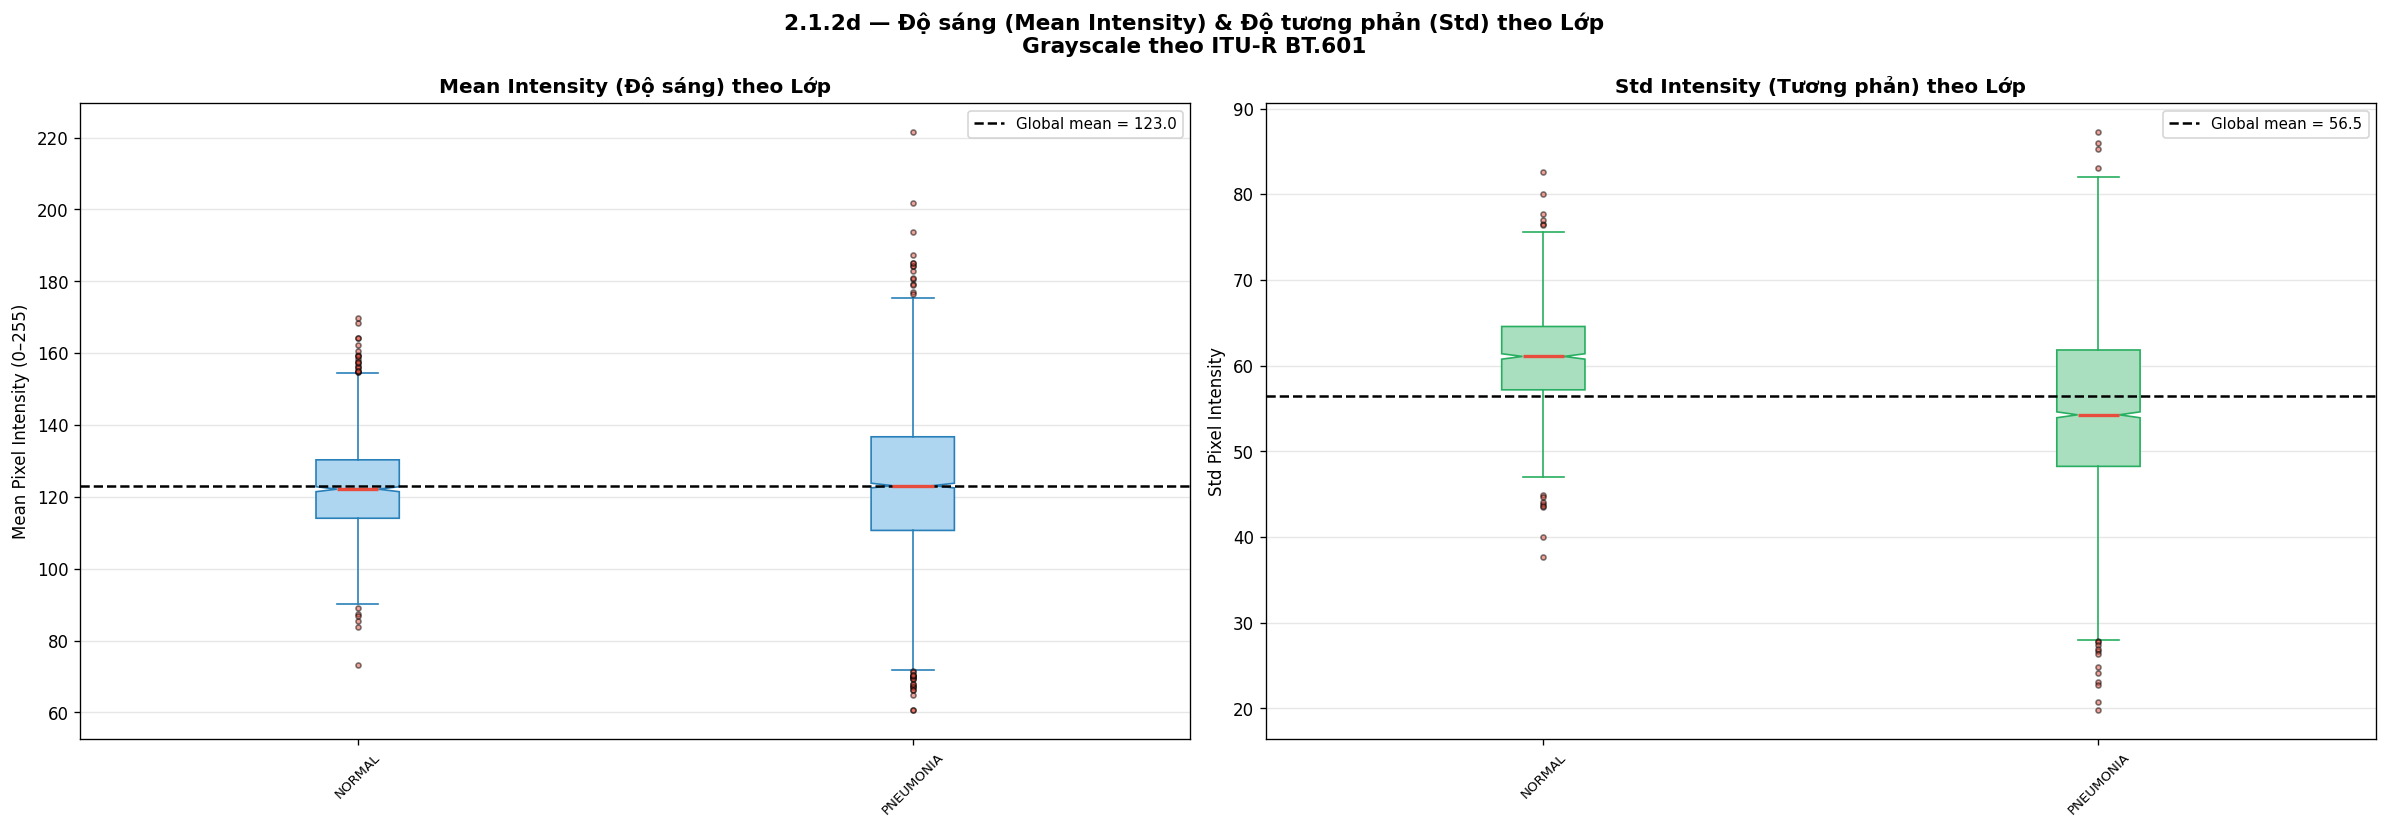


📊 Bảng tóm tắt Brightness & Contrast theo lớp:
      Lớp  Brightness Mean  Brightness Std  Contrast Mean  Contrast Std  N ảnh
   NORMAL           122.39           12.95          60.94          5.61   1341
PNEUMONIA           123.20           20.11          54.92         10.05   3875

📌 ANOVA test — độ sáng có khác nhau giữa các lớp?
  F-statistic = 1.92,  p-value = 1.66e-01
  → ❌ Không có sự khác biệt đáng kể

📌 ANOVA test — độ tương phản có khác nhau giữa các lớp?
  F-statistic = 433.85,  p-value = 1.28e-92
  → ✅ CÓ sự khác biệt có ý nghĩa thống kê (p < 0.05)


In [8]:
# Phân tích Độ sáng & Độ tương phản theo Lớp
#
# class_images & class_dirs được định nghĩa ở Cell 2.1.2b (imbalance)
# Nếu chạy cell này độc lập, cần chạy cell imbalance trước.

# Phân tích Độ sáng & Độ tương phản theo Lớp

selected_cls = class_dirs[:N_CLASSES_SHOW]
brightness   = defaultdict(list)   # mean intensity mỗi ảnh, theo lớp
contrast     = defaultdict(list)   # std intensity mỗi ảnh, theo lớp

print(f'Phân tích {N_CLASSES_SHOW} lớp, mỗi lớp tối đa {MAX_PER_CLASS} ảnh...')
print(f'Công thức Grayscale: ITU-R BT.601  →  Y = 0.299R + 0.587G + 0.114B')

for cls in tqdm(selected_cls, desc='Lớp'):
    for path in class_images[cls][:MAX_PER_CLASS]:
        try:
            arr  = np.array(
                Image.open(path).convert('RGB').resize(IMG_SIZE_DEFAULT),
                dtype=np.float32,
            )
            # Grayscale theo ITU-R BT.601 — thể hiện hiểu biết về weighted conversion
            gray = 0.299 * arr[:, :, 0] + 0.587 * arr[:, :, 1] + 0.114 * arr[:, :, 2]
            brightness[cls].append(float(gray.mean()))
            contrast[cls].append(float(gray.std()))
        except Exception:
            continue

# Global statistics — lưu vào biến tường minh
all_brightness_vals = [v for lst in brightness.values() for v in lst]
all_contrast_vals   = [v for lst in contrast.values()   for v in lst]

global_mean_intensity  = float(np.mean(all_brightness_vals))
global_std_intensity   = float(np.std(all_brightness_vals))
global_mean_contrast   = float(np.mean(all_contrast_vals))
global_std_contrast    = float(np.std(all_contrast_vals))

print('\n📌 Global statistics:')
print(f'  global_mean_intensity = {global_mean_intensity:.2f}')
print(f'  global_std_intensity  = {global_std_intensity:.2f}')
print(f'  global_mean_contrast  = {global_mean_contrast:.2f}')
print(f'  global_std_contrast   = {global_std_contrast:.2f}')

# Boxplot theo lớp
short = [c.replace('___', '\n').replace('_', ' ')[:20] for c in selected_cls]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('2.1.2d — Độ sáng (Mean Intensity) & Độ tương phản (Std) theo Lớp\n'
             'Grayscale theo ITU-R BT.601',
             fontsize=13, fontweight='bold')

# Boxplot Brightness
ax1.boxplot(
    [brightness[c] for c in selected_cls],
    labels=short,
    patch_artist=True,
    notch=True,                                          # CI của median
    boxprops=dict(facecolor='#aed6f1', color='#2980b9'),
    medianprops=dict(color='#e74c3c', lw=2),
    flierprops=dict(marker='o', markerfacecolor='#e74c3c', ms=3, alpha=0.5),
    whiskerprops=dict(color='#2980b9'),
    capprops=dict(color='#2980b9'),
)
ax1.axhline(global_mean_intensity, color='black', ls='--', lw=1.5,
            label=f'Global mean = {global_mean_intensity:.1f}')
ax1.set_title('Mean Intensity (Độ sáng) theo Lớp', fontweight='bold')
ax1.set_ylabel('Mean Pixel Intensity (0–255)')
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Boxplot Contrast
ax2.boxplot(
    [contrast[c] for c in selected_cls],
    labels=short,
    patch_artist=True,
    notch=True,
    boxprops=dict(facecolor='#a9dfbf', color='#27ae60'),
    medianprops=dict(color='#e74c3c', lw=2),
    flierprops=dict(marker='o', markerfacecolor='#e74c3c', ms=3, alpha=0.5),
    whiskerprops=dict(color='#27ae60'),
    capprops=dict(color='#27ae60'),
)
ax2.axhline(global_mean_contrast, color='black', ls='--', lw=1.5,
            label=f'Global mean = {global_mean_contrast:.1f}')
ax2.set_title('Std Intensity (Tương phản) theo Lớp', fontweight='bold')
ax2.set_ylabel('Std Pixel Intensity')
ax2.tick_params(axis='x', rotation=45, labelsize=8)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/2_1_2d_brightness_contrast.png', dpi=150, bbox_inches='tight')
plt.show()

# Bảng tóm tắt per-class
rows = []
for c in selected_cls:
    rows.append({
        'Lớp':              c[:35],
        'Brightness Mean':  round(np.mean(brightness[c]), 2),
        'Brightness Std':   round(np.std(brightness[c]),  2),
        'Contrast Mean':    round(np.mean(contrast[c]),   2),
        'Contrast Std':     round(np.std(contrast[c]),    2),
        'N ảnh':            len(brightness[c]),
    })
brightness_stats_df = pd.DataFrame(rows)
print('\n📊 Bảng tóm tắt Brightness & Contrast theo lớp:')
print(brightness_stats_df.to_string(index=False))

# ANOVA test — kiểm định brightness có khác nhau giữa các lớp không
f_stat_bright, p_val_bright = f_oneway(*[brightness[c] for c in selected_cls])
f_stat_contrast, p_val_contrast = f_oneway(*[contrast[c] for c in selected_cls])

anova_brightness_f  = float(f_stat_bright)
anova_brightness_p  = float(p_val_bright)
anova_contrast_f    = float(f_stat_contrast)
anova_contrast_p    = float(p_val_contrast)

print('\n📌 ANOVA test — độ sáng có khác nhau giữa các lớp?')
print(f'  F-statistic = {anova_brightness_f:.2f},  p-value = {anova_brightness_p:.2e}')
print(f'  → {"✅ CÓ sự khác biệt có ý nghĩa thống kê (p < 0.05)" if anova_brightness_p < 0.05 else "❌ Không có sự khác biệt đáng kể"}')

print('\n📌 ANOVA test — độ tương phản có khác nhau giữa các lớp?')
print(f'  F-statistic = {anova_contrast_f:.2f},  p-value = {anova_contrast_p:.2e}')
print(f'  → {"✅ CÓ sự khác biệt có ý nghĩa thống kê (p < 0.05)" if anova_contrast_p < 0.05 else "❌ Không có sự khác biệt đáng kể"}')

#### Nhận xét:
**1. Brightness (Mean Intensity) — Không có sự khác biệt đáng kể giữa hai lớp:**  
ANOVA cho F = 1.92, p = 0.166 > 0.05 → **không bác bỏ H₀**. Hai lớp có độ sáng trung bình gần như bằng nhau (122.39 vs 123.20 — chênh lệch chưa đến 1 pixel). Điều này có nghĩa là độ sáng tổng thể **không phải đặc trưng phân biệt** giữa phổi bình thường và viêm phổi, và việc chuẩn hóa brightness sẽ không ảnh hưởng đến khả năng phân loại.

**2. Contrast (Std Intensity) — Có sự khác biệt rất có ý nghĩa thống kê:**  
ANOVA cho F = 433.85, p ≈ 1.28×10⁻⁹² << 0.05 → **bác bỏ H₀ mạnh mẽ**. Lớp NORMAL có contrast cao hơn đáng kể (60.94 vs 54.92). Điều này phù hợp về mặt y tế: phổi viêm (PNEUMONIA) thường xuất hiện các vùng mờ đục (infiltrates, consolidation) làm giảm độ tương phản cục bộ — phổi bình thường có cấu trúc rõ nét hơn với sự phân tách rõ giữa vùng khí và mô.

**3. Độ phân tán (Std của Std) khác biệt rõ:**  
PNEUMONIA có Contrast Std = 10.05, gấp gần **1.8 lần** so với NORMAL (5.61). Điều này cho thấy mức độ tổn thương phổi trong lớp PNEUMONIA rất đa dạng — từ viêm nhẹ (contrast gần bình thường) đến viêm nặng (contrast rất thấp). Sự phân tán lớn này là một thách thức cho mô hình phân loại.

**4. Kết luận cho pipeline tiền xử lý:**  
Contrast là đặc trưng phân biệt lớp có ý nghĩa thống kê (p << 0.05), trong khi brightness thì không. Điều này gợi ý các kỹ thuật tăng cường tương phản (CLAHE, histogram equalization) trong bước preprocessing sẽ có tác động tích cực đến hiệu năng phân loại, bằng cách làm nổi bật sự chênh lệch contrast vốn có giữa hai lớp.